
Comparing ID 0:
  OLD: /Users/jpnousu/SpaFHy-Peat_private/example_inputs/forcing/Weather_id_0.csv
  NEW: /Users/jpnousu/SpaFHy-Peat_private/hiket_inputs/ensembles/sites/forcing/Weather_id_0.csv


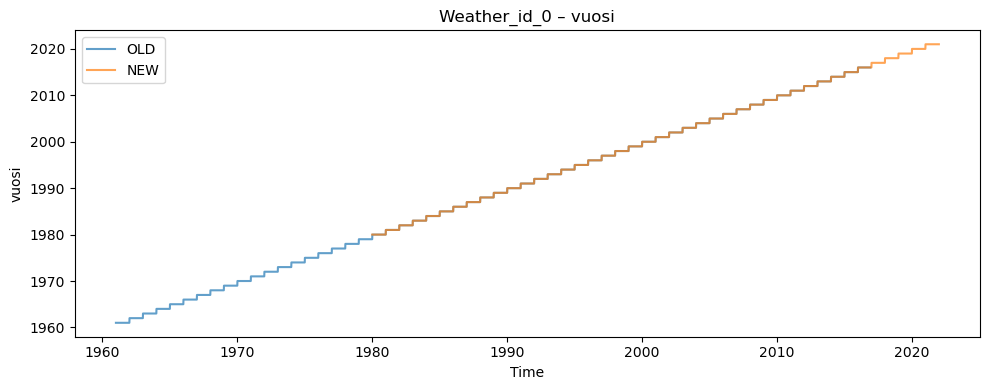

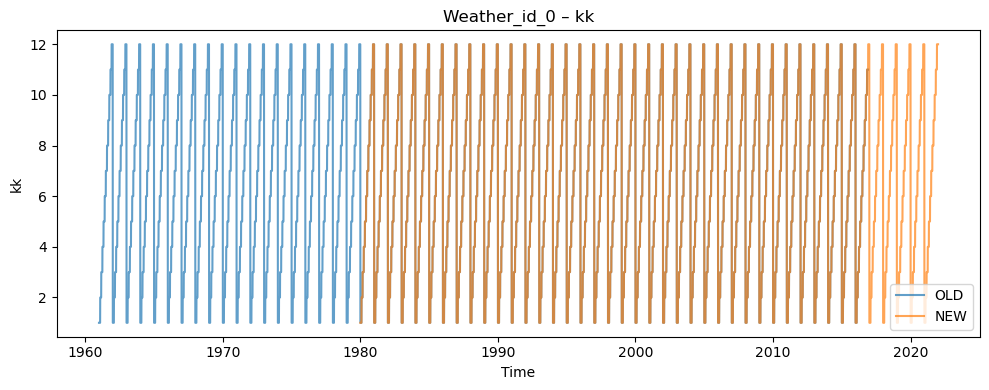

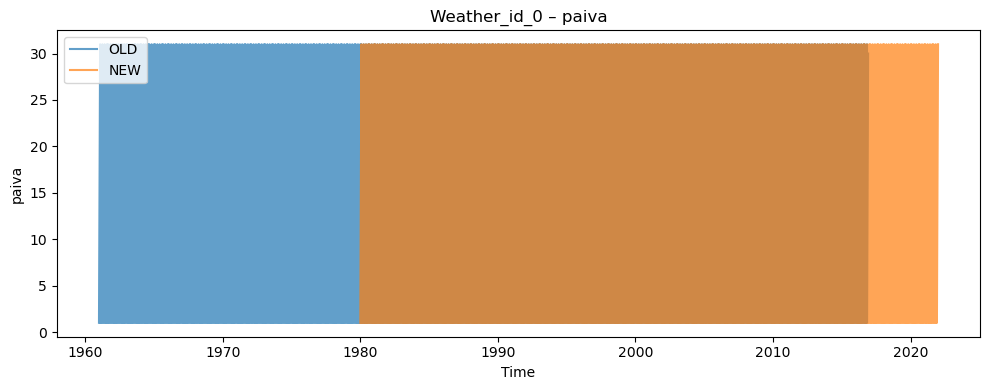

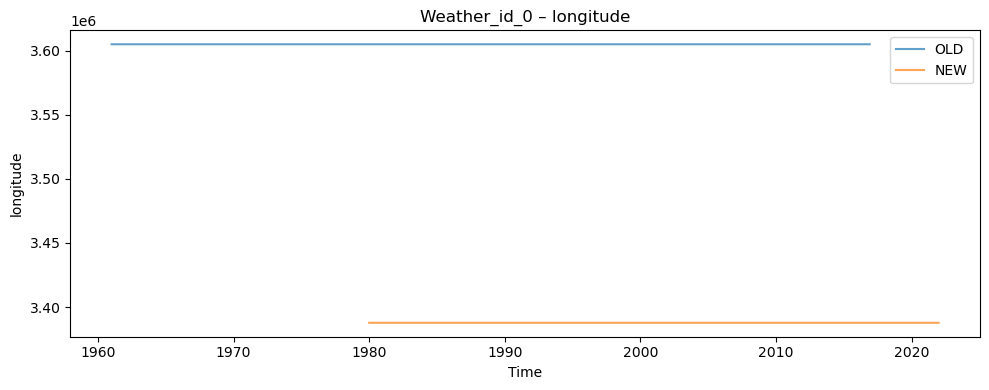

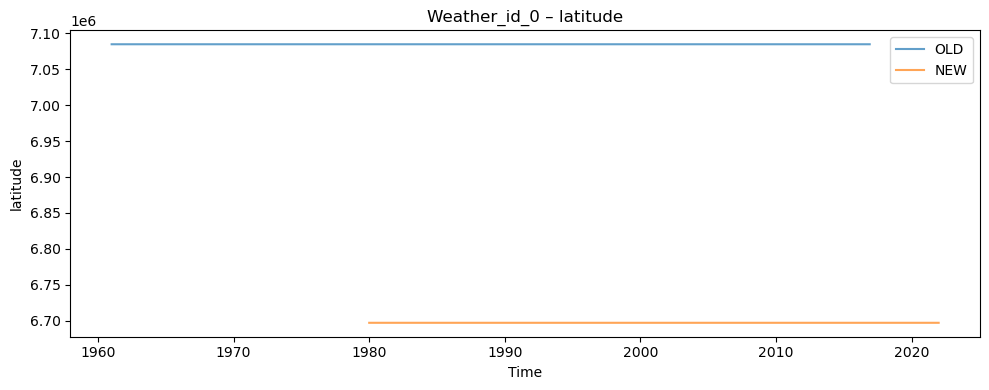

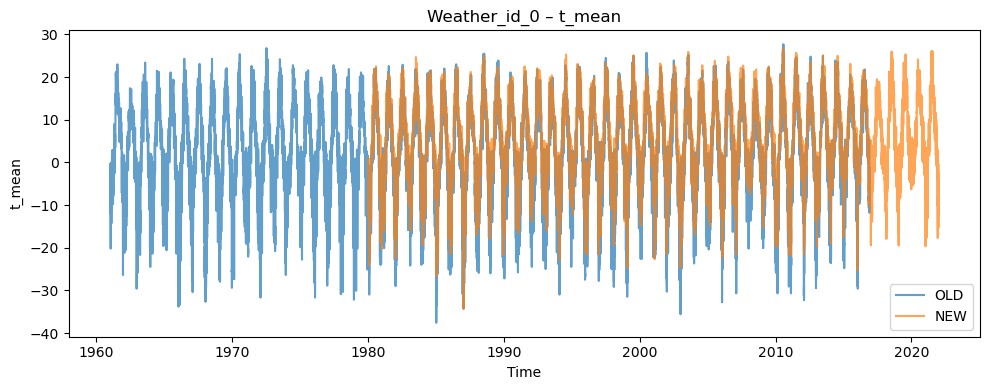

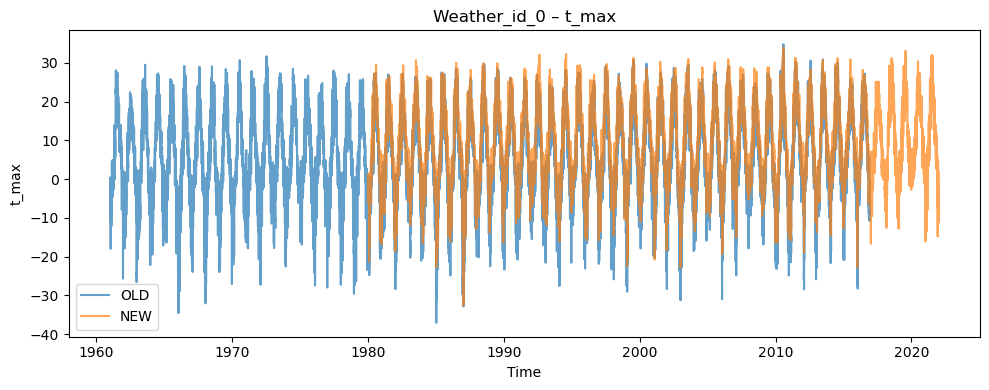

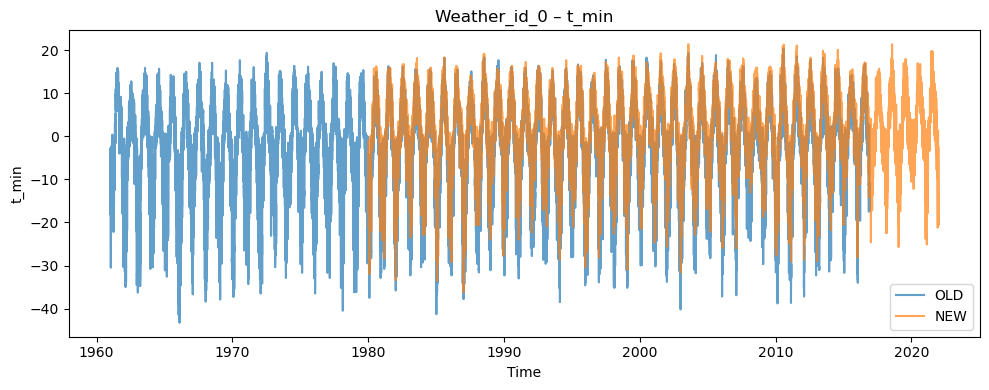

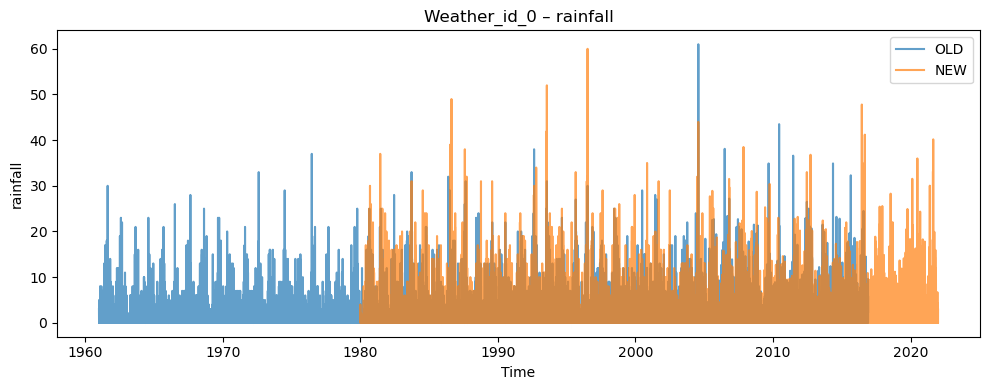

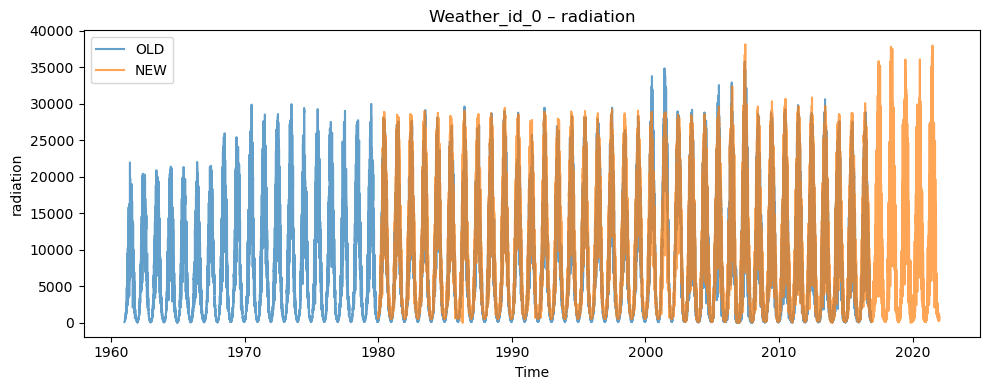

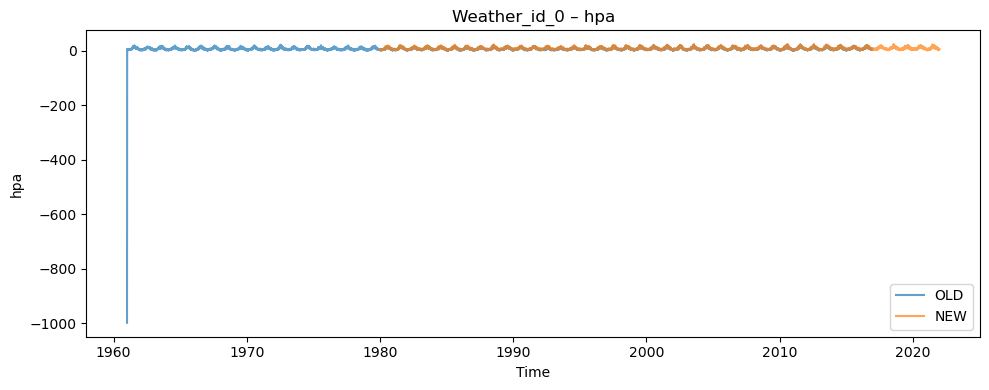

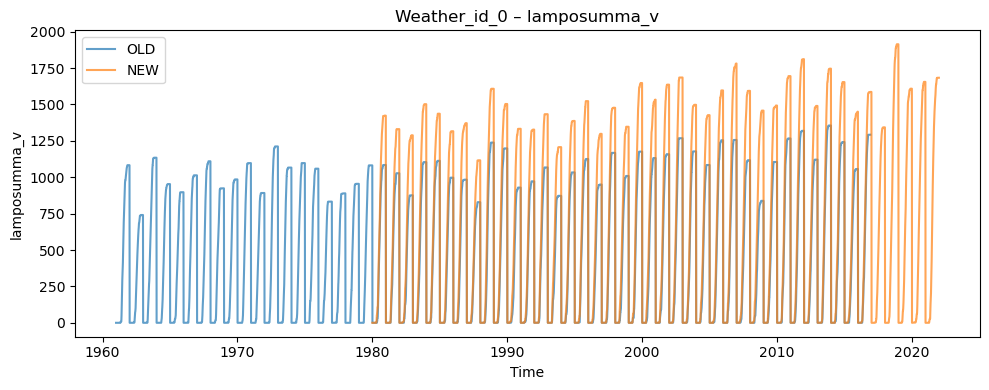


Comparing ID 1:
  OLD: /Users/jpnousu/SpaFHy-Peat_private/example_inputs/forcing/Weather_id_1.csv
  NEW: /Users/jpnousu/SpaFHy-Peat_private/hiket_inputs/ensembles/sites/forcing/Weather_id_1.csv


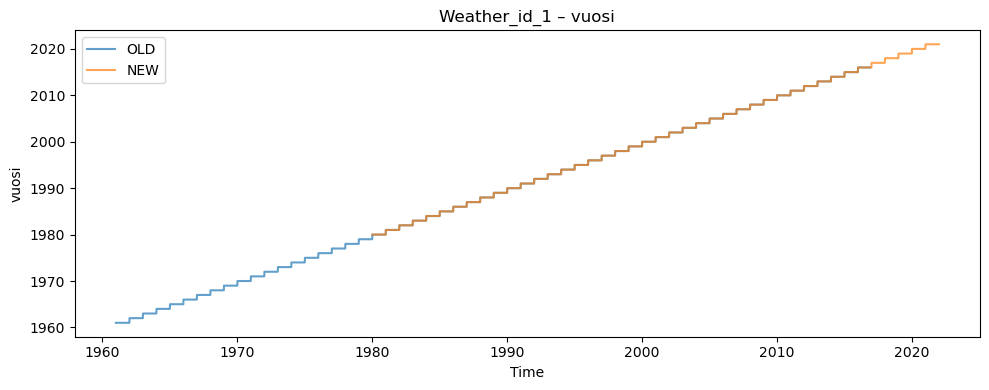

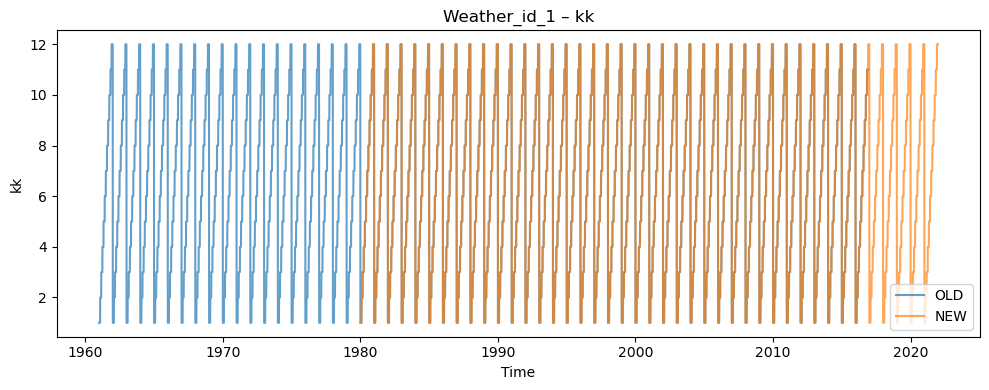

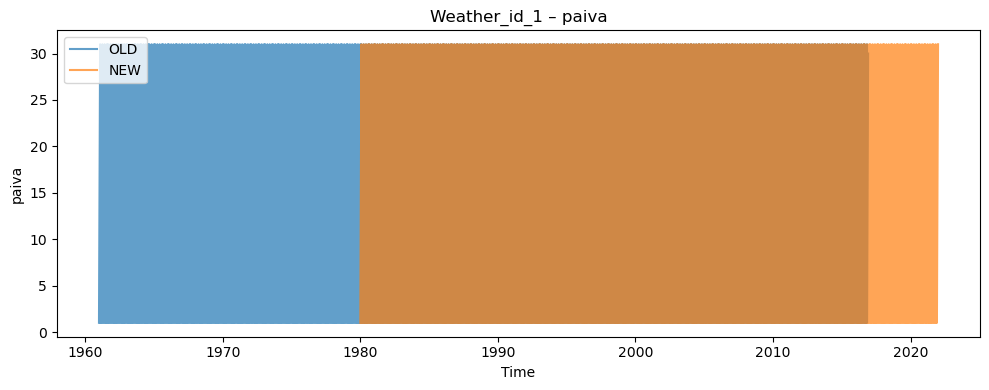

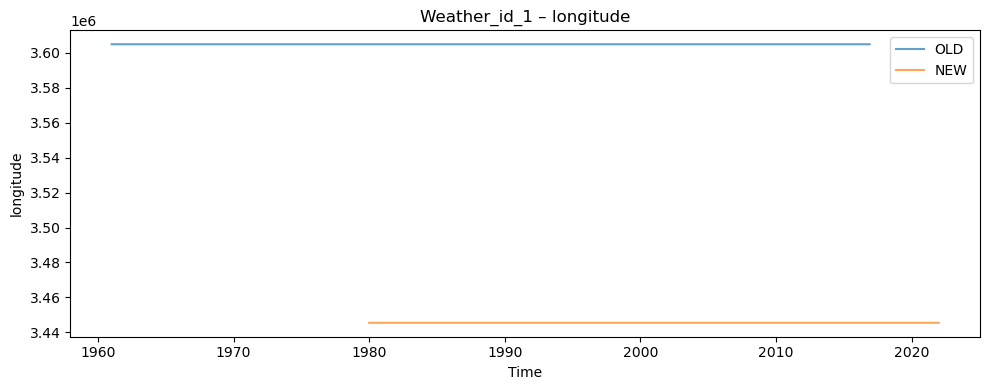

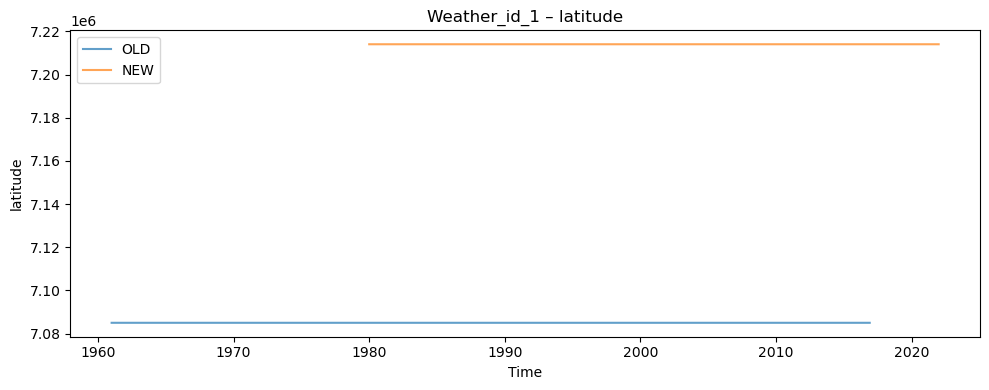

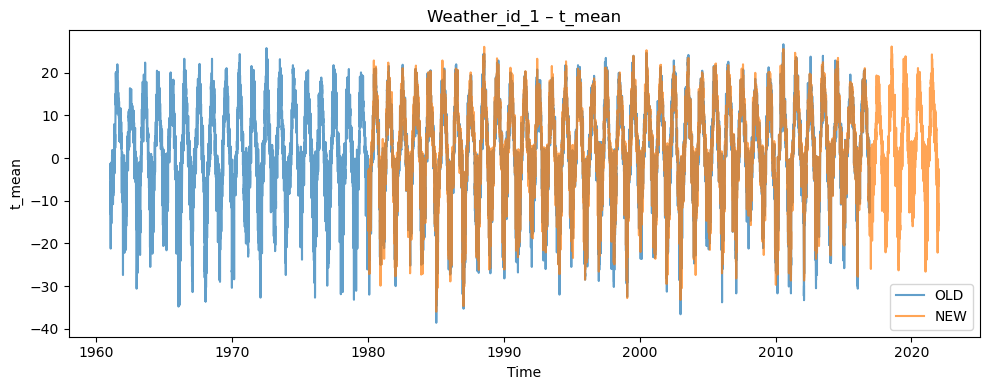

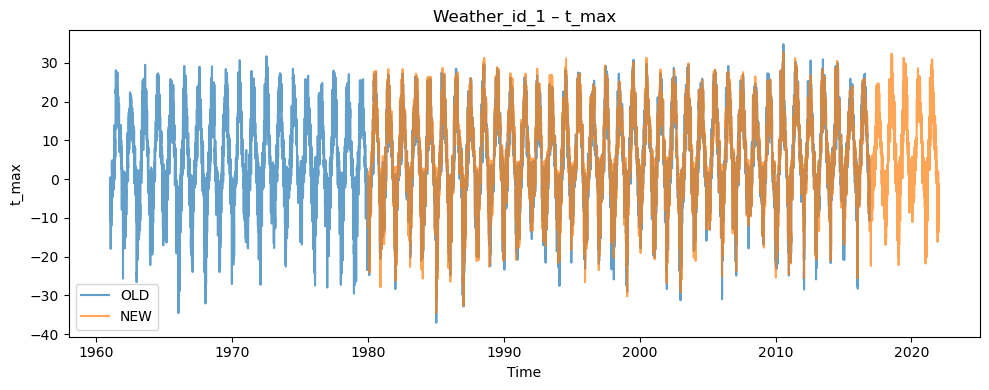

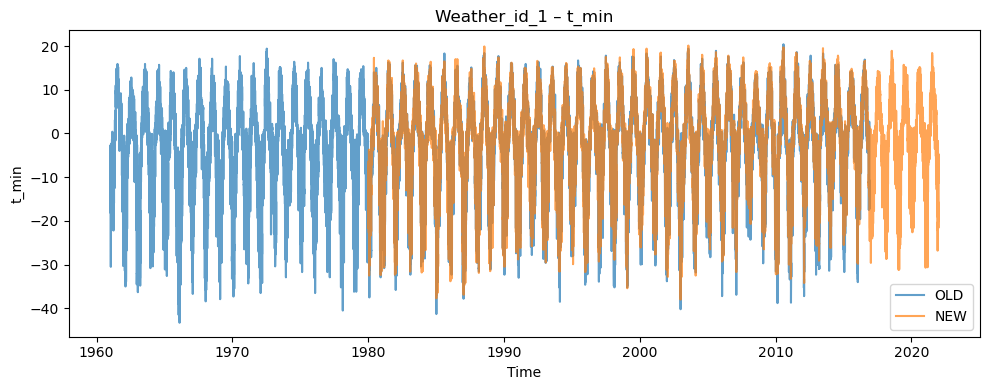

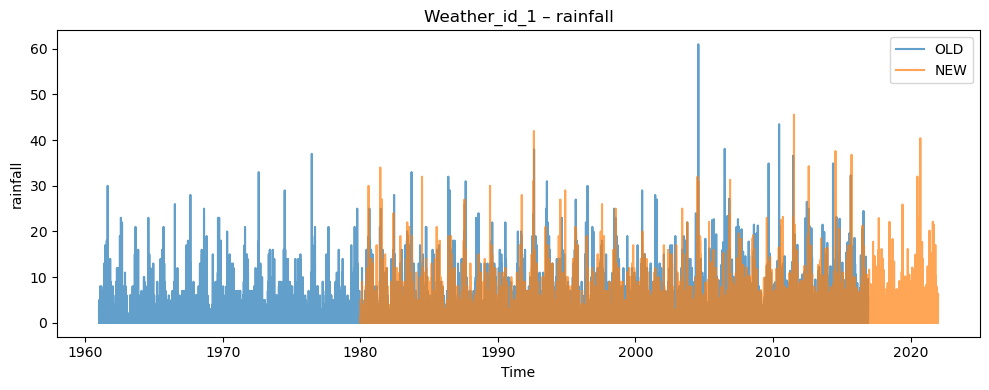

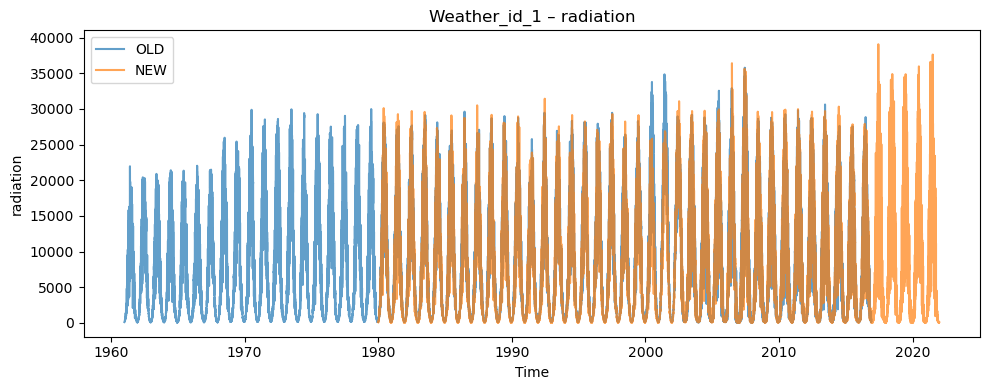

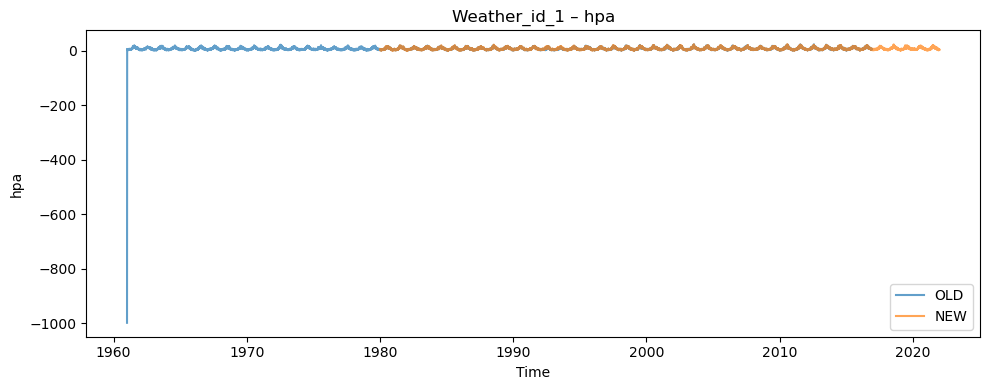

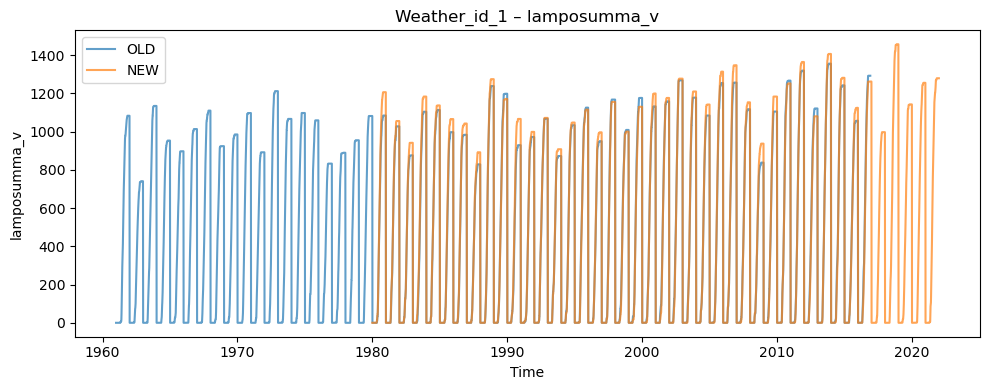

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Paths ----
new_path = Path("/Users/jpnousu/SpaFHy-Peat_private/hiket_inputs/ensembles/sites/forcing/")
old_path = Path("/Users/jpnousu/SpaFHy-Peat_private/example_inputs/forcing/")

# ---- Number of stations (adjust if needed) ----
num_ids = 2   # If you have Weather_id_0.csv and Weather_id_1.csv

# ---- Loop through files ----
for idx in range(num_ids):
    new_file = new_path / f"Weather_id_{idx}.csv"
    old_file = old_path / f"Weather_id_{idx}.csv"
    
    print(f"\nComparing ID {idx}:")
    print(f"  OLD: {old_file}")
    print(f"  NEW: {new_file}")

    # ---- Load CSVs ----
    old = pd.read_csv(old_file, sep=';', parse_dates=['aika'])
    new = pd.read_csv(new_file, sep=';', parse_dates=['aika'])
    
    # Set datetime index
    old = old.set_index('aika')
    new = new.set_index('aika')

    # Find common columns
    columns = [c for c in old.columns if c in new.columns]

    # ---- Plot each column ----
    for col in columns:
        plt.figure(figsize=(10, 4))
        plt.plot(old.index, old[col], label='OLD', alpha=0.7)
        plt.plot(new.index, new[col], label='NEW', alpha=0.7)
        plt.title(f"Weather_id_{idx} – {col}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.legend()
        plt.tight_layout()
        plt.show()
